# TQ_LTR：LambdaMART 截面排名動能策略

* **策略類型：** Pipeline 因子架構 — Learning to Rank（LTR）
* **交易標的：** 台灣 50 成分股
* **調倉頻率：** 月度再平衡
* **論文來源：** *Learning to Rank Enhancing Momentum Strategies Across Asset Classes*

---

## 📌 策略概述

### 核心概念：截面排名問題

傳統動能策略把「找出下個月漲最多的股票」當作**分類/迴歸問題**（預測報酬率）。
本論文提出：這其實是一個**排名問題（Learning to Rank）** — 我們不需要預測報酬的絕對大小，只需要預測**股票間的相對排名**。

使用 LambdaMART（NDCG 最優化的梯度提升排名模型），將多個動能因子組合成一個排名分數，
直接針對「哪幾支股票下個月漲最多」這個排名目標做學習。

### 特徵因子

| 特徵 | 說明 | Alpha 來源 |
|:---|:---|:---|
| **`baz`** | 三時間尺度 MACD 合成訊號（短/中/長） | 多頻動能 |
| **`vam`** | 21 日報酬 ÷ 21 日波動率 | 波動率調整動能 |
| **`mom_1m`** | 近 21 日報酬（約 22 個交易日） | 短期動能 |
| **`mom_3m`** | 跳過近 1 月的 3 月報酬（skip-1M） | 中期動能（避免短反轉） |
| **`mom_6m`** | 跳過近 1 月的 6 月報酬（skip-1M） | 中長期動能 |
| **`vol_21`** | 21 日日報酬標準差 | 波動率因子 |

### Walk-Forward 訓練邏輯

```
月份 T 的排名預測流程：
1. 訓練集：月份 [0, T-1] 的 (特徵, 未來1月報酬quintile標籤)
2. LambdaMART：最大化 NDCG@5（前 5 名排名準確度）
3. 預測：月份 T 各股票的 LTR 分數
4. 交易：買入 LTR 分數最高的前 10 支（等權）
```

**注意**：所有訓練、預測在 Zipline 回測前完成，透過 DataFrameLoader 注入。


## 📌 Phase 1：環境設定 & 參數

設定 TEJ API、回測區間與策略參數。

In [ ]:
%matplotlib inline
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import tejapi
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from logbook import Logger

os.environ['TEJAPI_BASE'] = 'https://api.tej.com.tw'
os.environ['TEJAPI_KEY']  = '請輸入API'
tejapi.ApiConfig.api_key  = os.getenv('TEJAPI_KEY')
tejapi.ApiConfig.api_base = os.getenv('TEJAPI_BASE')

log = Logger('LTR')

# 字型設定：優先使用 SourceHanSansTC（思源黑體繁體中文），Linux 環境無 Microsoft JhengHei
_font_path = '/app/SourceHanSansTC-Regular.otf'
if os.path.exists(_font_path):
    fm.fontManager.addfont(_font_path)
    _font_name = fm.FontProperties(fname=_font_path).get_name()
    plt.rcParams['font.sans-serif'] = [_font_name, 'DejaVu Sans']
    print(f'字型載入：{_font_name}')
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    print('警告：找不到 SourceHanSansTC-Regular.otf，中文可能無法顯示')
plt.rcParams['axes.unicode_minus'] = False

# -- backtest params --
start_date    = '2019-12-30'
end_date      = '2024-12-31'
capital_base  = 1_000_000

# -- pre-training data: 2016-2019 純訓練用，不進回測 --
PRETRAIN_START = '2016-01-01'

# -- strategy params --
TOP_N            = 10
LIQUIDITY_TOP_N  = 45
N_QUINTILE       = 5
MIN_TRAIN_MONTHS = 12

# -- BAZ params --
BAZ_PARAMS = [
    {'fast':  8, 'slow':  24},
    {'fast': 16, 'slow':  48},
    {'fast': 32, 'slow':  96},
]
FEAT_BUFFER = 130

# -- LightGBM LambdaMART params --
LGB_PARAMS = {
    'objective'        : 'lambdarank',
    'metric'           : 'ndcg',
    'ndcg_eval_at'     : [5, 10],
    'learning_rate'    : 0.05,
    'num_leaves'       : 31,
    'min_data_in_leaf' : 5,
    'verbose'          : -1,
    'seed'             : 42,
}
N_BOOST_ROUND = 100

# -- universe: 台灣 50 --
from zipline.sources.TEJ_Api_Data import get_universe
pool = get_universe(start_date, end_date, idx_id='IX0002')
print(f'Universe (TW50): {len(pool)} stocks')

os.environ['mdate']  = f'{start_date} {end_date}'
os.environ['ticker'] = ' '.join(pool)
print(f'Pre-train: {PRETRAIN_START} ~ {start_date}  (4 年訓練資料)')
print(f'Backtest:  {start_date} ~ {end_date}')


字型載入：Source Han Sans TC
Currently used TEJ API key call quota 19/100000 (0.02%)
Currently used TEJ API key data quota 778442/10000000 (7.78%)
Universe (TW50): 69 stocks
Pre-train: 2016-01-01 ~ 2019-12-30  (4 年訓練資料)
Backtest:  2019-12-30 ~ 2024-12-31


## 📌 Phase 2：資料下載 & 特徵工程

從 TEJ API 下載收盤價（`close_d`）與日報酬率（`roi`）。
- `close_d` → 回傳欄位 `Close`，用於計算 BAZ 特徵（EWM MACD 在價格層面運算）
- `roi` → 回傳欄位 `ROI`（已含除權息調整），用於計算 VAM / MOM / VOL 特徵與 forward return 標籤

特徵計算需要比 `start_date` 更早的資料（BAZ 的 EWM 緩衝），
所以 `feat_start` 往前取 `FEAT_BUFFER` 個交易日。


In [2]:
from TejToolAPI.TejToolAPI import get_history_data

# 從 PRETRAIN_START 往前再加 FEAT_BUFFER 緩衝（BAZ EWM 暖機）
feat_start = (pd.Timestamp(PRETRAIN_START) - pd.tseries.offsets.BDay(FEAT_BUFFER + 10)).strftime('%Y-%m-%d')

print(f'Downloading price data: {feat_start} ~ {end_date}')
price_raw = get_history_data(
    ticker  = pool,
    columns = ['close_d', 'roi'],
    start   = feat_start,
    end     = end_date
)

price_raw['mdate'] = pd.to_datetime(price_raw['mdate'])
price_raw = price_raw.sort_values(['coid', 'mdate']).reset_index(drop=True)

print(f'Price data: {price_raw.shape}')
print(f'Date range: {price_raw.mdate.min().date()} ~ {price_raw.mdate.max().date()}')
print(f'Tickers: {price_raw.coid.nunique()}')
print(price_raw.head(3))


Currently used TEJ API key call quota 12/100000 (0.01%)
Currently used TEJ API key data quota 602623/10000000 (6.03%)
Price data: (155419, 4)
Date range: 2015-06-22 ~ 2024-12-31
Tickers: 69
   coid      mdate  Close     ROI
0  1101 2015-06-22  38.00  0.2639
1  1101 2015-06-23  38.55  1.4474
2  1101 2015-06-24  38.90  0.9079


## 📌 特徵工程函數

### BAZ 訊號（直接移植自 TQ_BAZ notebook）

三組快慢線 EWM MACD，每組計算：
1. `MACD = EWM(fast) - EWM(slow)`
2. 標準化：`x = MACD / σ(近63日價格)`
3. Response function：`φ(x) = x·exp(−x²/4)/0.89`（壓縮極端值）

三組等權合成 → `baz_composite`

### VAM / MOM / VOL

- `VAM`：21日報酬 ÷ 21日波動率（與 TQ_VAM 相同）
- `MOM_3M/6M`：跳過最近1個月（skip-1M），避免短期反轉偏差
- `VOL_21`：21日日報酬標準差


In [3]:
# ── BAZ 函數（與 TQ_BAZ 完全一致）─────────────────────────────────────
def _ewm(prices: np.ndarray, span: int) -> np.ndarray:
    alpha  = 2.0 / (span + 1)
    result = np.empty_like(prices, dtype=float)
    result[0] = prices[0]
    for i in range(1, len(prices)):
        result[i] = alpha * prices[i] + (1 - alpha) * result[i - 1]
    return result

def _baz_response(x: float) -> float:
    return x * np.exp(-x ** 2 / 4.0) / 0.89

def calc_single_baz(prices: np.ndarray, fast: int, slow: int) -> float:
    if len(prices) < slow + 10:
        return np.nan
    macd = _ewm(prices, fast)[-1] - _ewm(prices, slow)[-1]
    vol  = np.std(prices[-min(63, len(prices)):])
    if vol < 1e-8:
        return np.nan
    return _baz_response(macd / vol)

def calc_composite_baz(prices: np.ndarray) -> float:
    sigs = [calc_single_baz(prices, p['fast'], p['slow']) for p in BAZ_PARAMS]
    valid = [s for s in sigs if not np.isnan(s)]
    return float(np.mean(valid)) if valid else np.nan


# ── ROI 複利報酬 helper（全 NaN 回傳 NaN）────────────────────────────────
def _prod_ret(roi_slice: np.ndarray) -> float:
    valid = roi_slice[~np.isnan(roi_slice)]
    if len(valid) == 0:
        return np.nan
    return float(np.prod(1.0 + valid) - 1.0)


# ── 截面特徵計算 ─────────────────────────────────────────────────────────
# close_arr：收盤價序列（BAZ 用）
# roi_arr  ：除權息還原日報酬序列（VAM / MOM / VOL 用）
def compute_features(close_arr: np.ndarray, roi_arr: np.ndarray) -> dict:
    feats = {}
    n = len(roi_arr)

    # BAZ：EWM MACD 在價格層面運算，維持用 close
    feats['baz'] = calc_composite_baz(close_arr)

    # MOM_1M、VOL_21、VAM（用 ROI，避免 close 除權息跳空造成假訊號）
    if n >= 21:
        r21            = roi_arr[-21:]
        mom_1m         = _prod_ret(r21)
        vol_21         = float(np.nanstd(r21))
        feats['mom_1m'] = mom_1m
        feats['vol_21'] = vol_21
        feats['vam']    = (mom_1m / vol_21) if (vol_21 > 1e-8 and not np.isnan(mom_1m)) else np.nan
    else:
        feats['mom_1m'] = np.nan
        feats['vol_21'] = np.nan
        feats['vam']    = np.nan

    # MOM_3M: skip-1M，roi[-63:-21] 對應 close[-64]~close[-22] 的漲幅
    feats['mom_3m'] = _prod_ret(roi_arr[-63:-21]) if n >= 63 else np.nan

    # MOM_6M: skip-1M，roi[-126:-21] 對應 close[-127]~close[-22] 的漲幅
    feats['mom_6m'] = _prod_ret(roi_arr[-126:-21]) if n >= 126 else np.nan

    return feats

FEATURE_COLS = ['baz', 'vam', 'mom_1m', 'mom_3m', 'mom_6m', 'vol_21']
print(f'特徵欄位: {FEATURE_COLS}')
print('特徵函數載入完成')


特徵欄位: ['baz', 'vam', 'mom_1m', 'mom_3m', 'mom_6m', 'vol_21']
特徵函數載入完成


## 📌 月度截面資料集建立

為每個月度再平衡日（每月第一個交易日）計算各股票的截面特徵，
以及 forward 1-month return（作為標籤的基礎）。

月度標籤：在每個月份截面內，按 forward return 分為 5 個分位組（0=最差, 4=最佳）。
LambdaMART 學習最大化這個截面排名的 NDCG 指標。


In [5]:
# ── 建立 pivot tables ───────────────────────────────────────────────────
close_pivot = (
    price_raw[['coid', 'mdate', 'Close']]
    .dropna(subset=['Close'])
    .set_index(['mdate', 'coid'])['Close']
    .unstack('coid')
    .sort_index()
)

roi_pivot = (
    price_raw[['coid', 'mdate', 'ROI']]
    .dropna(subset=['ROI'])
    .set_index(['mdate', 'coid'])['ROI']
    .unstack('coid')
    .sort_index()
)

# ── 月度再平衡日：從 PRETRAIN_START 到 end_date（含預訓練期）──────────────
trading_days = close_pivot.index
monthly_dates = (
    pd.Series(trading_days, index=trading_days)
    .resample('MS').first()
    .dropna()
    .values
)
monthly_dates = [d for d in monthly_dates
                 if pd.Timestamp(PRETRAIN_START) <= pd.Timestamp(d) <= pd.Timestamp(end_date)]

backtest_start_ts = pd.Timestamp(start_date)
pretrain_months   = [d for d in monthly_dates if pd.Timestamp(d) < backtest_start_ts]
backtest_months   = [d for d in monthly_dates if pd.Timestamp(d) >= backtest_start_ts]

print(f'預訓練月份: {len(pretrain_months)} 個（{pd.Timestamp(pretrain_months[0]).strftime("%Y-%m")} ~ {pd.Timestamp(pretrain_months[-1]).strftime("%Y-%m")}）')
print(f'回測月份:   {len(backtest_months)} 個（{pd.Timestamp(backtest_months[0]).strftime("%Y-%m")} ~ {pd.Timestamp(backtest_months[-1]).strftime("%Y-%m")}）')

# ── 計算截面特徵（全部月份）────────────────────────────────────────────────
print('\n計算月度截面特徵...')
feat_records = []
for rebal_date in monthly_dates:
    rebal_ts   = pd.Timestamp(rebal_date)
    hist_close = close_pivot.loc[:rebal_ts]
    hist_roi   = roi_pivot.loc[:rebal_ts]
    for ticker in close_pivot.columns:
        close_series = hist_close[ticker].dropna().values
        roi_series   = hist_roi[ticker].dropna().values
        if len(close_series) < BAZ_PARAMS[-1]['slow'] + 10:
            continue
        feats = compute_features(close_series, roi_series)
        feats['date']   = rebal_ts
        feats['ticker'] = ticker
        feat_records.append(feats)

feat_df = pd.DataFrame(feat_records)
feat_df['date'] = pd.to_datetime(feat_df['date'])
feat_df = feat_df.dropna(subset=['baz', 'vam', 'mom_1m'])
print(f'特徵矩陣: {feat_df.shape}，每月平均 {feat_df.groupby("date").size().mean():.1f} 支')

# ── Forward return 標籤（全部月份）──────────────────────────────────────────
print('\n計算 forward return 標籤...')
fwd_records = []
for i in range(len(monthly_dates) - 1):
    date_t  = pd.Timestamp(monthly_dates[i])
    date_t1 = pd.Timestamp(monthly_dates[i + 1])
    mask    = (roi_pivot.index > date_t) & (roi_pivot.index <= date_t1)
    period_roi = roi_pivot.loc[mask]
    if len(period_roi) == 0:
        continue
    cum_ret = (1 + period_roi).prod(min_count=1) - 1
    for ticker, ret in cum_ret.items():
        if not np.isnan(ret):
            fwd_records.append({'date': date_t, 'ticker': ticker, 'fwd_ret': float(ret)})

fwd_df = pd.DataFrame(fwd_records)

def assign_quintile(group):
    n = len(group)
    if n < N_QUINTILE:
        group['label'] = (group['fwd_ret'].rank(pct=True) * (N_QUINTILE-1)).astype(int)
    else:
        try:
            group['label'] = pd.qcut(group['fwd_ret'], N_QUINTILE, labels=False, duplicates='drop').astype(int)
        except ValueError:
            group['label'] = (group['fwd_ret'].rank(pct=True) * (N_QUINTILE-1)).astype(int)
    return group

fwd_df = fwd_df.groupby('date', group_keys=False).apply(assign_quintile)
fwd_df = fwd_df.dropna(subset=['label'])
fwd_df['label'] = fwd_df['label'].astype(int)

# ── 合併 ──────────────────────────────────────────────────────────────────
model_df = feat_df.merge(fwd_df[['date', 'ticker', 'label', 'fwd_ret']], on=['date', 'ticker'], how='inner')
model_df = model_df.dropna(subset=FEATURE_COLS + ['label'])
model_df = model_df.sort_values(['date', 'ticker']).reset_index(drop=True)

print(f'\n訓練資料集: {len(model_df)} 筆，{model_df.date.nunique()} 個月份')
print(f'  預訓練期樣本: {len(model_df[model_df.date < backtest_start_ts])} 筆')
print(f'  回測期樣本:   {len(model_df[model_df.date >= backtest_start_ts])} 筆')
print(f'標籤分布:\n{model_df["label"].value_counts().sort_index().to_string()}')


預訓練月份: 48 個（2016-01 ~ 2019-12）
回測月份:   60 個（2020-01 ~ 2024-12）

計算月度截面特徵...
特徵矩陣: (7231, 8)，每月平均 67.0 支

計算 forward return 標籤...

訓練資料集: 7121 筆，107 個月份
  預訓練期樣本: 3115 筆
  回測期樣本:   4006 筆
標籤分布:
label
0    1455
1    1379
2    1452
3    1378
4    1457


## 📌 Phase 3：Walk-Forward LambdaMART 訓練

在月份 T，使用 [0, T-1] 所有月份訓練，預測月份 T 的截面排名。

**LambdaMART 的 group 參數**：每個月份截面是一個 query group。
`groups` 列表的每個元素 = 該月份截面中的股票數（可變，TW50 約 42-50）。
`sum(groups)` 必須等於訓練集總樣本數，順序必須與 X_train 的行排序完全一致。


In [6]:
print('Walk-Forward LambdaMART Training...')
print('=' * 60)

unique_months = sorted(model_df['date'].unique())
all_scores    = []

for t_idx in range(MIN_TRAIN_MONTHS, len(unique_months)):
    predict_month = unique_months[t_idx]
    train_months  = unique_months[:t_idx]

    train_df = model_df[model_df['date'].isin(train_months)].copy()
    pred_df  = model_df[model_df['date'] == predict_month].copy()

    if len(pred_df) == 0:
        continue

    X_train = train_df[FEATURE_COLS].values.astype(np.float32)
    y_train = train_df['label'].values.astype(np.int32)
    X_pred  = pred_df[FEATURE_COLS].values.astype(np.float32)

    # LambdaMART group：每月截面樣本數（必須與 train_df 行順序一致）
    train_groups = (
        train_df.groupby('date').size()
        .loc[train_months]
        .values.tolist()
    )
    assert sum(train_groups) == len(train_df), 'Group size 不一致！'

    lgb_train = lgb.Dataset(X_train, label=y_train, group=train_groups, free_raw_data=False)
    model = lgb.train(LGB_PARAMS, lgb_train, num_boost_round=N_BOOST_ROUND)

    scores = model.predict(X_pred)
    for i, (_, row) in enumerate(pred_df.iterrows()):
        all_scores.append({'date': predict_month, 'ticker': row['ticker'], 'ltr_score': float(scores[i])})

    if t_idx % 6 == 0 or t_idx == len(unique_months) - 1:
        print(f'  [{predict_month.strftime("%Y-%m")}] train={len(train_months)}mo/{len(train_df)}筆 '
              f'| pred={len(pred_df)}股 | score=[{scores.min():.3f},{scores.max():.3f}]')

# ── 最後一個月：用完整訓練集預測（沒有 forward return 但要交易）──────────
last_month = pd.Timestamp(monthly_dates[-1])
last_feat  = feat_df[feat_df['date'] == last_month].dropna(subset=FEATURE_COLS)
if len(last_feat) > 0:
    X_last = last_feat[FEATURE_COLS].values.astype(np.float32)
    X_all  = model_df[FEATURE_COLS].values.astype(np.float32)
    y_all  = model_df['label'].values.astype(np.int32)
    g_all  = model_df.groupby('date').size().values.tolist()
    lgb_full = lgb.Dataset(X_all, label=y_all, group=g_all, free_raw_data=False)
    m_final  = lgb.train(LGB_PARAMS, lgb_full, num_boost_round=N_BOOST_ROUND)
    s_last   = m_final.predict(X_last)
    for i, (_, row) in enumerate(last_feat.iterrows()):
        all_scores.append({'date': last_month, 'ticker': row['ticker'], 'ltr_score': float(s_last[i])})
    print(f'  [{last_month.strftime("%Y-%m")}] 最終月份預測完成（{len(last_feat)} 股）')

scores_df = pd.DataFrame(all_scores)
scores_df['date'] = pd.to_datetime(scores_df['date'])
scores_df.to_parquet('ltr_scores.parquet')
print(f'\nWalk-forward 完成！{len(scores_df)} 筆分數，{scores_df.date.nunique()} 個月份')
print(scores_df.groupby('date')['ltr_score'].agg(['count','mean','std']).tail(6).to_string())


Walk-Forward LambdaMART Training...
  [2017-01] train=12mo/756筆 | pred=63股 | score=[-2.145,1.095]
  [2017-07] train=18mo/1140筆 | pred=65股 | score=[-2.453,2.343]
  [2018-01] train=24mo/1530筆 | pred=65股 | score=[-1.292,1.079]
  [2018-07] train=30mo/1920筆 | pred=65股 | score=[-1.066,2.346]
  [2019-01] train=36mo/2312筆 | pred=66股 | score=[-1.812,1.512]
  [2019-07] train=42mo/2710筆 | pred=67股 | score=[-1.663,0.892]
  [2020-01] train=48mo/3115筆 | pred=68股 | score=[-1.196,1.177]
  [2020-07] train=54mo/3523筆 | pred=68股 | score=[-0.925,1.342]
  [2021-01] train=60mo/3931筆 | pred=68股 | score=[-0.954,0.966]
  [2021-07] train=66mo/4339筆 | pred=68股 | score=[-0.903,1.760]
  [2022-01] train=72mo/4747筆 | pred=67股 | score=[-0.850,1.285]
  [2022-07] train=78mo/5149筆 | pred=68股 | score=[-1.072,1.257]
  [2023-01] train=84mo/5557筆 | pred=68股 | score=[-0.978,1.172]
  [2023-07] train=90mo/5965筆 | pred=68股 | score=[-0.974,1.834]
  [2024-01] train=96mo/6373筆 | pred=68股 | score=[-0.774,1.511]
  [2024-07] train=10

## 📌 Phase 4：Zipline 回測設定

將 Walk-Forward 預測的 LTR 分數透過 DataFrameLoader 注入 Pipeline。

**日期對齊說明**：
- LTR 分數在月初（每月第一個交易日）更新一次
- DataFrameLoader 自動向前填充（forward-fill），月內其他交易日使用月初分數
- 搭配 `date_rules.month_start()` 月初調倉，不存在 look-ahead bias


In [7]:
from zipline.data.run_ingest import simple_ingest
from zipline.data import bundles
from zipline.pipeline.loaders.frame import DataFrameLoader
from zipline.pipeline.data import Column, DataSet
from zipline.pipeline.domain import TW_EQUITIES

# ── Ingest 股價資料 ──────────────────────────────────────────────────────
pools = pool + ['IR0001']
print(f'Ingesting {len(pools)} tickers...')

# 往前 2 個月，讓 AverageDollarVolume(window_length=30) 回測第一天就有足夠歷史資料
# 不這樣做的話，Pipeline 前 ~30 個交易日找不到流動性標的，回測會晚於 benchmark 起跑
ingest_start = (pd.Timestamp(start_date) - pd.DateOffset(months=2)).strftime('%Y%m%d')

simple_ingest(
    name       = 'tquant',
    tickers    = pools,
    start_date = ingest_start,        # 比回測起點早 2 個月
    end_date   = end_date.replace('-', '')
)
print(f'Ingest 完成！(資料起始: {ingest_start}，回測起始: {start_date.replace("-", "")})')

# ── 建立 LTR Score 的 wide-format DataFrame ──────────────────────────────
bundle_data = bundles.load('tquant')
sids    = bundle_data.asset_finder.equities_sids
assets  = bundle_data.asset_finder.retrieve_all(sids)
sym_map = {a.symbol: a for a in assets}   # symbol str → Asset object

ltr_df = pd.read_parquet('ltr_scores.parquet')
ltr_df['date'] = pd.to_datetime(ltr_df['date'])

# Long → Wide（index=date, columns=ticker）
ltr_wide = ltr_df.pivot(index='date', columns='ticker', values='ltr_score')

# 將 ticker symbol 轉換為 Asset 物件（DataFrameLoader 要求）
ltr_wide.columns = ltr_wide.columns.map(sym_map)
ltr_wide = ltr_wide.loc[:, ltr_wide.columns.notna()]  # 過濾 bundle 找不到的 ticker

# 加 UTC timezone（DataFrameLoader 必要）
ltr_wide.index = pd.DatetimeIndex(ltr_wide.index).tz_localize('UTC')

print(f'LTR wide-format: {ltr_wide.shape}')
print(f'日期範圍: {ltr_wide.index[0].date()} ~ {ltr_wide.index[-1].date()}')

# ── CustomDataset ─────────────────────────────────────────────────────────
class LTRDataset(DataSet):
    """
    LambdaMART walk-forward LTR 分數。
    月初更新，DataFrameLoader 自動 forward-fill 至月底。
    值域為 LightGBM lambdarank 的 raw score（浮點數），僅用於截面排名。
    """
    ltr_score = Column(dtype=float)
    domain    = TW_EQUITIES

transform_data = {
    LTRDataset.ltr_score: DataFrameLoader(LTRDataset.ltr_score, ltr_wide)
}
print('CustomDataset & DataFrameLoader 建立完成')

Ingesting 70 tickers...
Now ingesting data.


[2026-04-29 01:15:24.686706] INFO: zipline.data.bundles.core: Ingesting tquant.


Merging daily equity files:


[2026-04-29 01:15:37.036231] INFO: zipline.data.bundles.core: Ingest tquant successfully.


Currently used TEJ API key call quota 18/100000 (0.02%)
Currently used TEJ API key data quota 778292/10000000 (7.78%)
End of ingesting tquant.
Please call function `get_bundle(start_dt = pd.Timestamp('20191030', tz = 'utc'),end_dt = pd.Timestamp('20241231' ,tz = 'utc'))` in `zipline.data.data_portal` to check data.
Currently used TEJ API key call quota 18/100000 (0.02%)
Currently used TEJ API key data quota 778292/10000000 (7.78%)
Ingest 完成！(資料起始: 20191030，回測起始: 20191230)
LTR wide-format: (96, 69)
日期範圍: 2017-01-03 ~ 2024-12-02
CustomDataset & DataFrameLoader 建立完成


## 📌 Pipeline & 策略主體

Pipeline 包含兩個欄位：`ltr_score`（LTR 排名分數）與 `dollar_volume`（流動性篩選用）。
`before_trading_start` **每個交易日**更新 Pipeline 輸出與 `context.stocks` 持股清單；
實際下單由 `rebalance` 負責，只在 **月初** 透過 `schedule_function(date_rules.month_start())` 執行。


In [8]:
from zipline.pipeline import Pipeline, CustomFactor
from zipline.pipeline.data import EquityPricing
from zipline.api import (
    attach_pipeline, pipeline_output,
    order_target_percent, set_commission, set_slippage, set_benchmark,
    record, schedule_function, date_rules, time_rules, symbol
)
from zipline.finance import commission, slippage


class AverageDollarVolume(CustomFactor):
    window_length = 30
    inputs        = [EquityPricing.close, EquityPricing.volume]
    def compute(self, today, assets, out, close, volume):
        out[:] = np.nanmean(close * volume, axis=0)


def make_pipeline():
    ltr           = LTRDataset.ltr_score.latest
    dollar_volume = AverageDollarVolume()
    liquid        = dollar_volume.top(LIQUIDITY_TOP_N)
    return Pipeline(
        columns={'ltr_score': ltr, 'dollar_volume': dollar_volume},
        screen=liquid & ltr.notnull()
    )


def initialize(context):
    set_commission(commission.Custom_TW_Commission(
        min_trade_cost = 20,
        discount       = 1.0,
        tax            = 0.003
    ))
    set_slippage(slippage.VolumeShareSlippage(
        volume_limit = 0.025,
        price_impact = 0.05
    ))
    set_benchmark(symbol('IR0001'))
    attach_pipeline(make_pipeline(), 'ltr_pipe')
    schedule_function(
        rebalance,
        date_rules.month_start(days_offset=0),
        time_rules.market_open()
    )
    context.month_count = 0


def before_trading_start(context, data):
    output = pipeline_output('ltr_pipe')
    output['ltr_score'] = pd.to_numeric(output['ltr_score'], errors='coerce')
    if len(output) == 0:
        context.stocks = []
        context.output = output
        return
    context.stocks = output.nlargest(TOP_N, 'ltr_score').index.tolist()
    context.output = output


def rebalance(context, data):
    context.month_count += 1
    today = data.current_dt.date()
    if len(context.stocks) == 0:
        log.warn(f'[{today}] No stocks, skip')
        return

    target_w = 1.0 / len(context.stocks)
    out = context.output

    for stock in context.portfolio.positions:
        if stock not in context.stocks:
            order_target_percent(stock, 0.0)
    for stock in context.stocks:
        if data.can_trade(stock):
            order_target_percent(stock, target_w)

    top_scores = out.loc[context.stocks, 'ltr_score']
    record(
        n_positions  = len(context.stocks),
        ltr_top_mean = float(top_scores.mean()),
        ltr_spread   = float(top_scores.mean() - out['ltr_score'].mean()),
    )
    print(f'\n[{today}] #{context.month_count} | {len(context.stocks)} stocks | each={target_w:.1%}')
    for s in sorted(context.stocks, key=lambda x: -out.loc[x, 'ltr_score']):
        print(f'  {s.symbol:6s}  LTR={out.loc[s, "ltr_score"]:+.4f}')

print('Strategy ready.')

Strategy ready.


## 📌 績效分析函數

四張圖：累積報酬 / LTR Spread（因子效力）/ 回撤曲線 / 月度報酬分布


In [19]:
def analyze(context, perf):
    fig, axes = plt.subplots(4, 1, figsize=(14, 16))

    ax1 = axes[0]
    (1+perf['returns']).cumprod().sub(1).plot(ax=ax1, label='LTR 策略', lw=2, color='steelblue')
    (1+perf['benchmark_return']).cumprod().sub(1).plot(ax=ax1, label='加權指數', lw=1.5, color='gray', alpha=0.7)
    ax1.axhline(0, color='black', lw=0.8, ls='--')
    ax1.set_title('LambdaMART LTR 動能策略 — 績效總覽', fontsize=13, fontweight='bold')
    ax1.set_ylabel('累積報酬'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    if 'ltr_spread' in perf.columns:
        perf['ltr_spread'].plot(ax=ax2, color='green', lw=1.5, label='LTR Spread (Top10 vs 全宇宙)')
        ax2.axhline(0, color='black', lw=0.8, ls='--')
    ax2.set_title('LTR 截面分數差（Top 10 均值 − 全宇宙均值）'); ax2.legend(); ax2.grid(True, alpha=0.3)

    ax3 = axes[2]
    cum = (1+perf['returns']).cumprod()
    dd  = cum/cum.cummax()-1
    dd.plot(ax=ax3, color='crimson', lw=1.5)
    ax3.fill_between(dd.index, dd.values, 0, color='crimson', alpha=0.25)
    ax3.set_title('策略回撤曲線'); ax3.grid(True, alpha=0.3)

    ax4 = axes[3]
    monthly = perf['returns'].resample('M').apply(lambda x: (1 + x).prod() - 1)
    monthly.plot(kind='bar', ax=ax4,
                     color=['green' if r > 0 else 'red' for r in monthly],
                     alpha=0.7, width=0.8)
    ax4.axhline(0, color='black', linewidth=0.8)
    ax4.set_ylabel('月報酬率')
    ax4.set_xlabel('月份')
    ax4.set_title('月度報酬分布')
    ax4.set_xticklabels([t.strftime('%Y-%m') for t in monthly.index], rotation=45, ha='right')
    ax4.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('ltr_strategy_performance.png', dpi=150, bbox_inches='tight')
    plt.show()

    total_ret  = (perf['portfolio_value'].iloc[-1]/capital_base - 1)*100
    annual_ret = ((perf['portfolio_value'].iloc[-1]/capital_base)**(252/len(perf)) - 1)*100
    max_dd     = perf['max_drawdown'].min()*100
    sharpe     = perf['sharpe'].dropna().iloc[-1]
    sortino    = perf['sortino'].dropna().iloc[-1]
    monthly_w  = (monthly>0).mean()*100

    print('\n' + '='*55)
    print('  LambdaMART LTR 動能策略 — 績效摘要')
    print('='*55)
    print(f'  回測期間  : {start_date} ~ {end_date}')
    print(f'  總報酬    : {total_ret:>+.2f}%')
    print(f'  年化報酬  : {annual_ret:>+.2f}%')
    print(f'  最大回撤  : {max_dd:.2f}%')
    print(f'  Sharpe    : {sharpe:.3f}')
    print(f'  Sortino   : {sortino:.3f}')
    print(f'  月度勝率  : {monthly_w:.1f}%')
    print('='*55)

    perf.to_csv('ltr_perf_result.csv')
    print('  結果已存至 ltr_perf_result.csv')

print('analyze ready.')


analyze ready.


## 📌 執行回測

注意：`custom_loader=transform_data` 讓 Pipeline 知道如何讀取 LTRDataset。

  開始回測：LambdaMART LTR 動能策略
  期間：2019-12-30 ~ 2024-12-31
  宇宙：TW50 | LTR Top 10，等權重

[2020-01-02] #1 | 10 stocks | each=10.0%
  6415    LTR=+1.1767
  2207    LTR=+1.0929
  2345    LTR=+0.9232
  5871    LTR=+0.8421
  1590    LTR=+0.6461
  2454    LTR=+0.5885
  6669    LTR=+0.3364
  2317    LTR=+0.3139
  3034    LTR=+0.2579
  2886    LTR=+0.1560

[2020-02-03] #2 | 10 stocks | each=10.0%
  3017    LTR=+0.8746
  1590    LTR=+0.8637
  3661    LTR=+0.8592
  2408    LTR=+0.4126
  2327    LTR=+0.4000
  2379    LTR=+0.3509
  3037    LTR=+0.2390
  2330    LTR=-0.0779
  6505    LTR=-0.1099
  2474    LTR=-0.1546

[2020-03-02] #3 | 10 stocks | each=10.0%
  2345    LTR=+1.7303
  3661    LTR=+0.8202
  3034    LTR=+0.8109
  1590    LTR=+0.7174
  3037    LTR=+0.4956
  5871    LTR=+0.2766
  2327    LTR=-0.0665
  3008    LTR=-0.1437
  2892    LTR=-0.1754
  2409    LTR=-0.1943

[2020-04-01] #4 | 10 stocks | each=10.0%
  1301    LTR=+2.0129
  2327    LTR=+1.5364
  6415    LTR=+1.4579
  3037    LTR=+1.4286
 

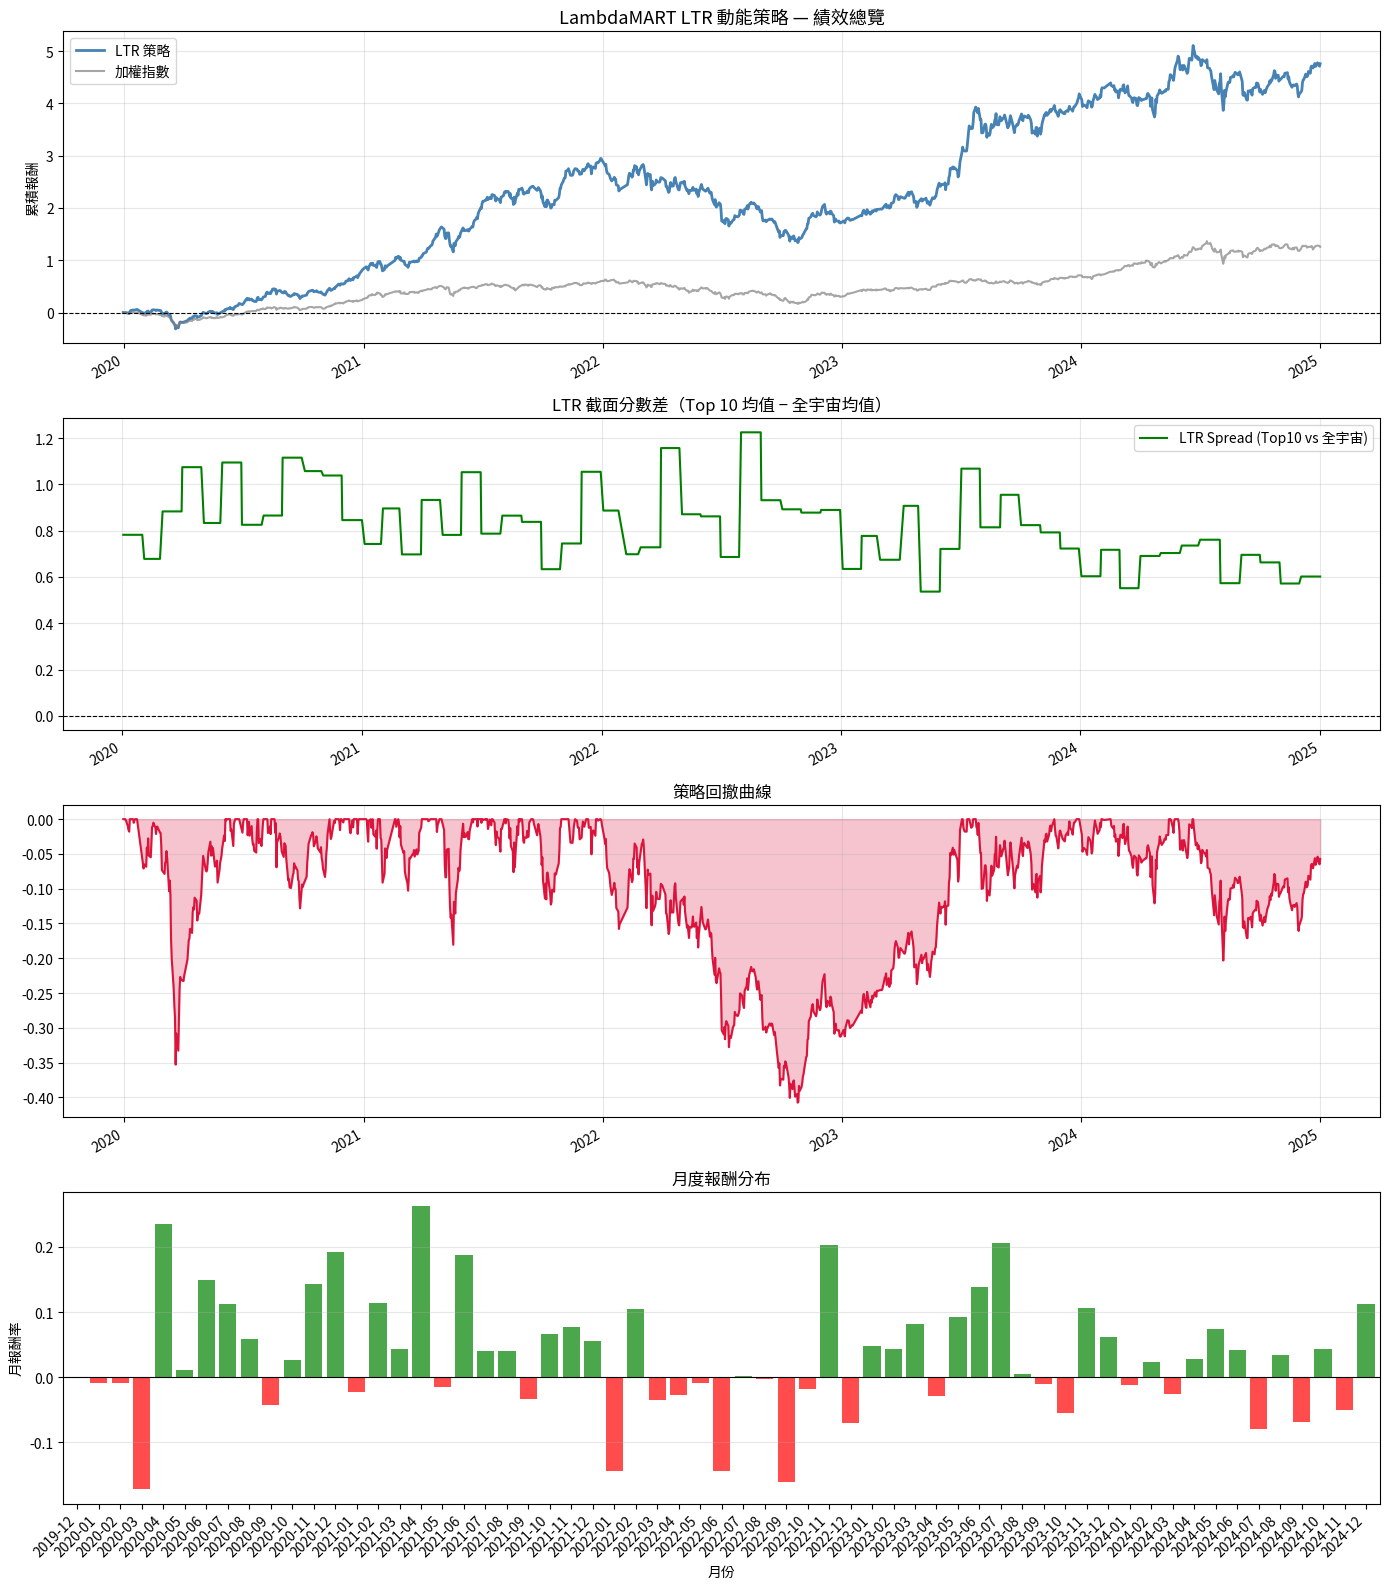


  LambdaMART LTR 動能策略 — 績效摘要
  回測期間  : 2019-12-30 ~ 2024-12-31
  總報酬    : +475.96%
  年化報酬  : +43.66%
  最大回撤  : -40.76%
  Sharpe    : 1.379
  Sortino   : 1.983
  月度勝率  : 59.0%
  結果已存至 ltr_perf_result.csv

回測完成！


In [20]:
from zipline import run_algorithm

print('='*60)
print('  開始回測：LambdaMART LTR 動能策略')
print(f'  期間：{start_date} ~ {end_date}')
print(f'  宇宙：TW50 | LTR Top {TOP_N}，等權重')
print('='*60)

results = run_algorithm(
    start                = pd.Timestamp(start_date, tz='utc'),
    end                  = pd.Timestamp(end_date,   tz='utc'),
    initialize           = initialize,
    before_trading_start = before_trading_start,
    analyze              = analyze,
    bundle               = 'tquant',
    capital_base         = capital_base,
    data_frequency       = 'daily',
    custom_loader        = transform_data
)

print('\n回測完成！')


## 📌 Pyfolio 完整報告（選用）

Start date,2019-12-30
End date,2024-12-31
Total months,58
,Backtest
Annual return,18.348%
Cumulative returns,125.74%
Annual volatility,18.61%
Sharpe ratio,1.00
Calmar ratio,0.64
Stability,0.76
Max drawdown,-28.553%


Start date,2019-12-30
End date,2024-12-31
Total months,58
,Backtest
Annual return,43.656%
Cumulative returns,475.965%
Annual volatility,29.43%
Sharpe ratio,1.38
Calmar ratio,1.07
Stability,0.82
Max drawdown,-40.757%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,40.76,2021-12-28,2022-10-25,2023-07-03,363
1,35.29,2020-01-20,2020-03-19,2020-06-03,87
2,20.32,2024-06-20,2024-08-05,NaT,NaN
3,18.06,2021-04-29,2021-05-17,2021-06-15,32
4,12.83,2020-08-17,2020-09-25,2020-11-09,58


Top 10 long positions of all time,max
sid,
2609,20.41%
2615,17.63%
6446,16.69%
1605,16.67%
3661,15.24%
2603,14.80%
3017,14.55%
2382,13.68%
3231,13.67%


Top 10 short positions of all time,max
sid,


Top 10 positions of all time,max
sid,
2609,20.41%
2615,17.63%
6446,16.69%
1605,16.67%
3661,15.24%
2603,14.80%
3017,14.55%
2382,13.68%
3231,13.67%


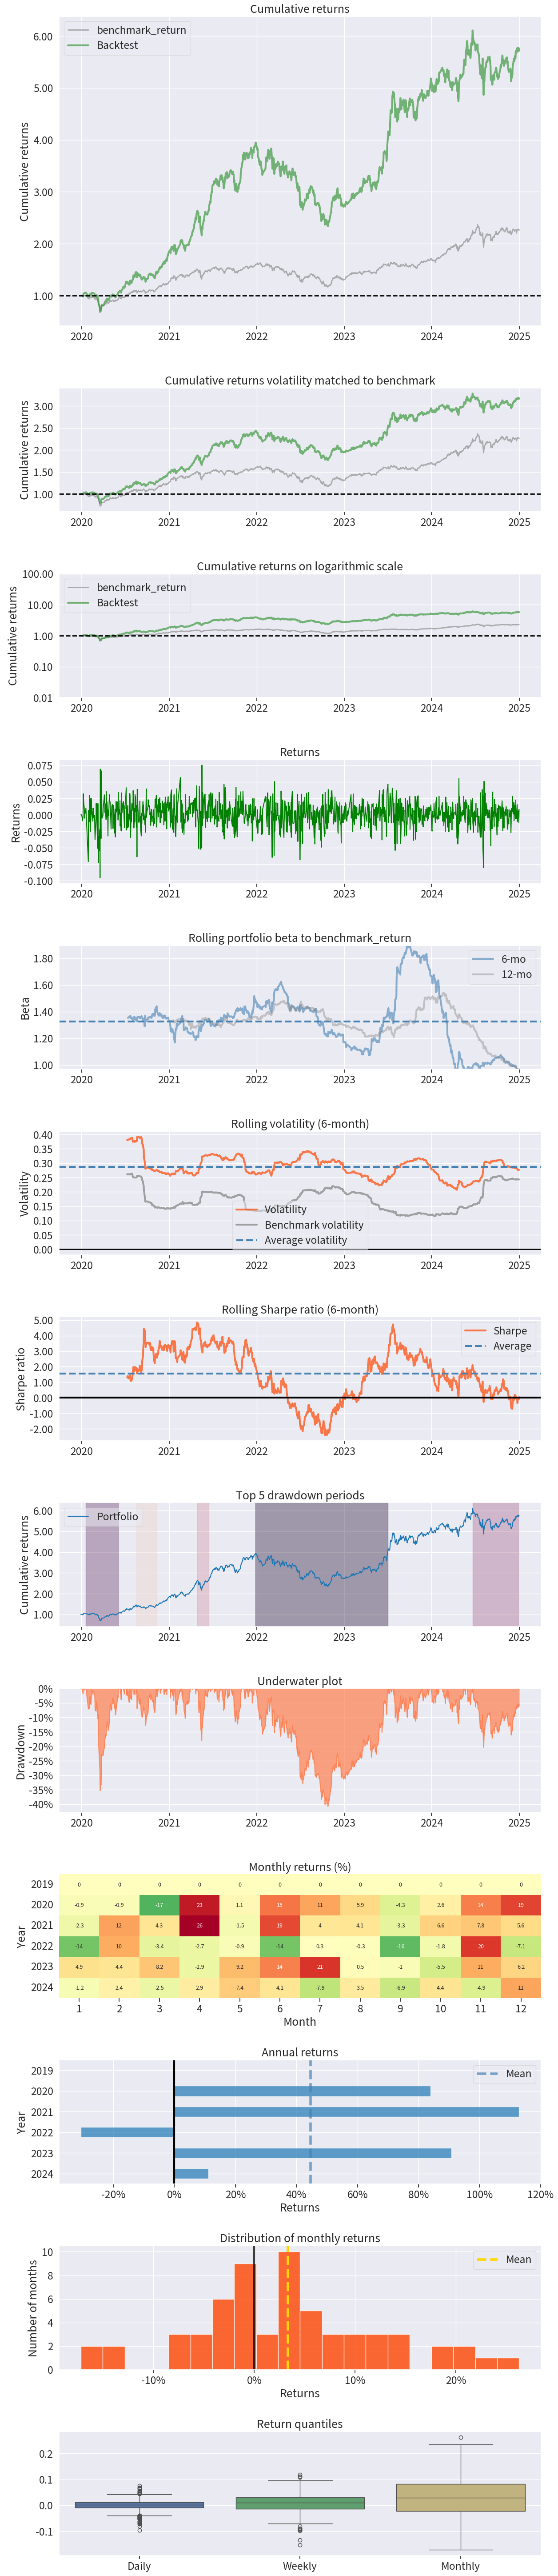

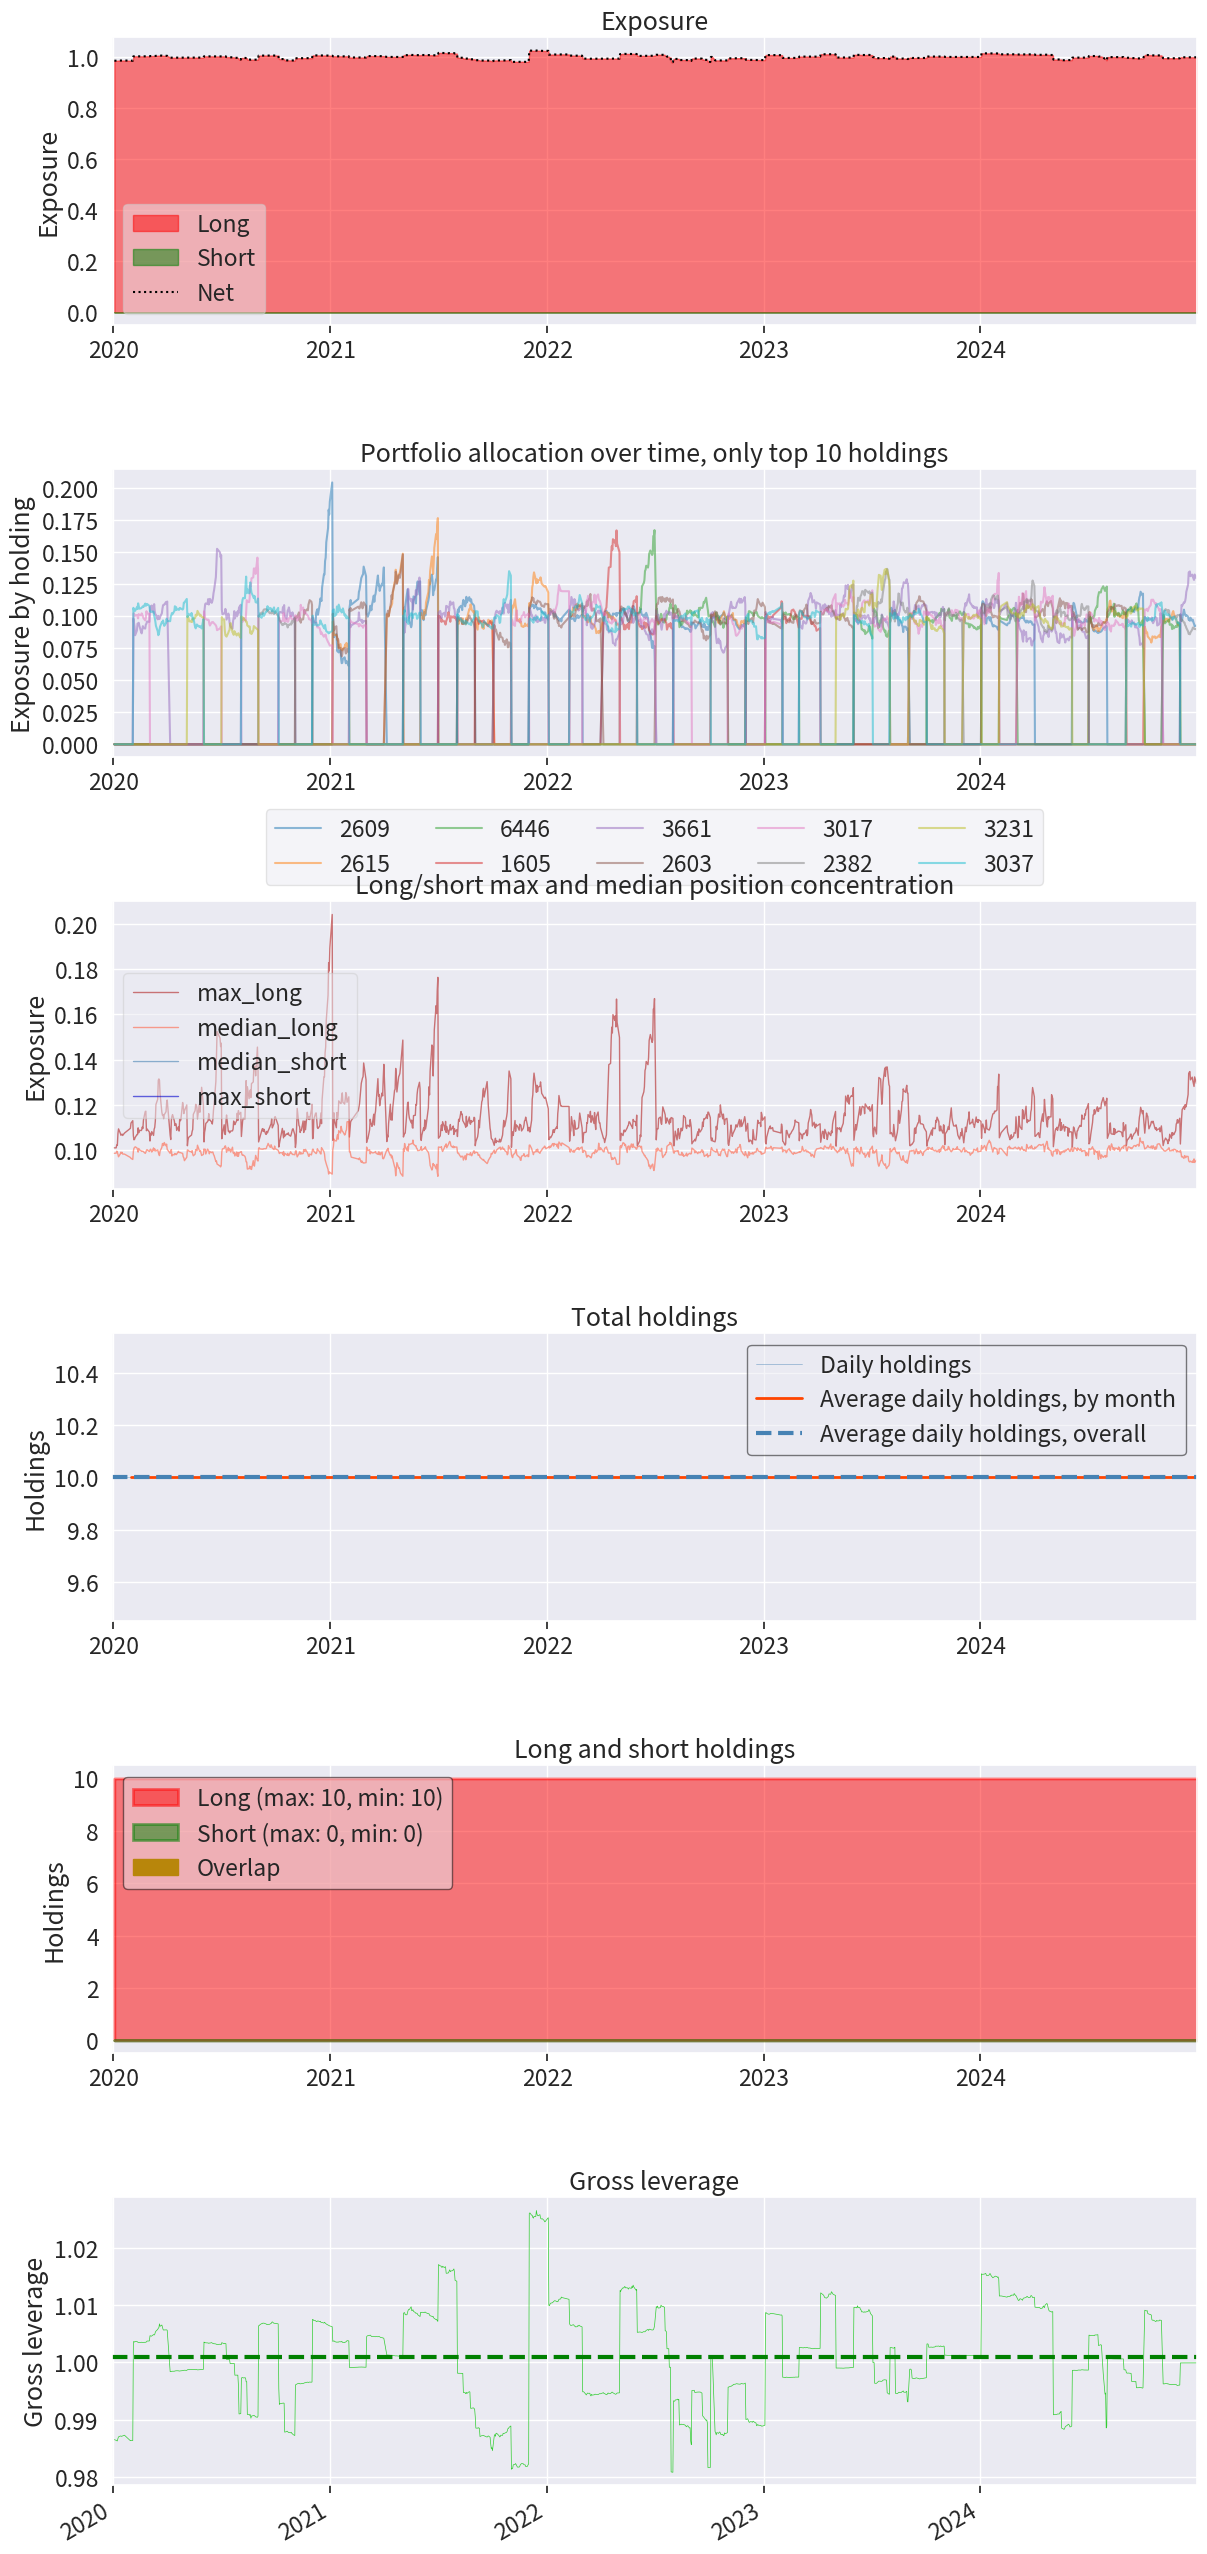

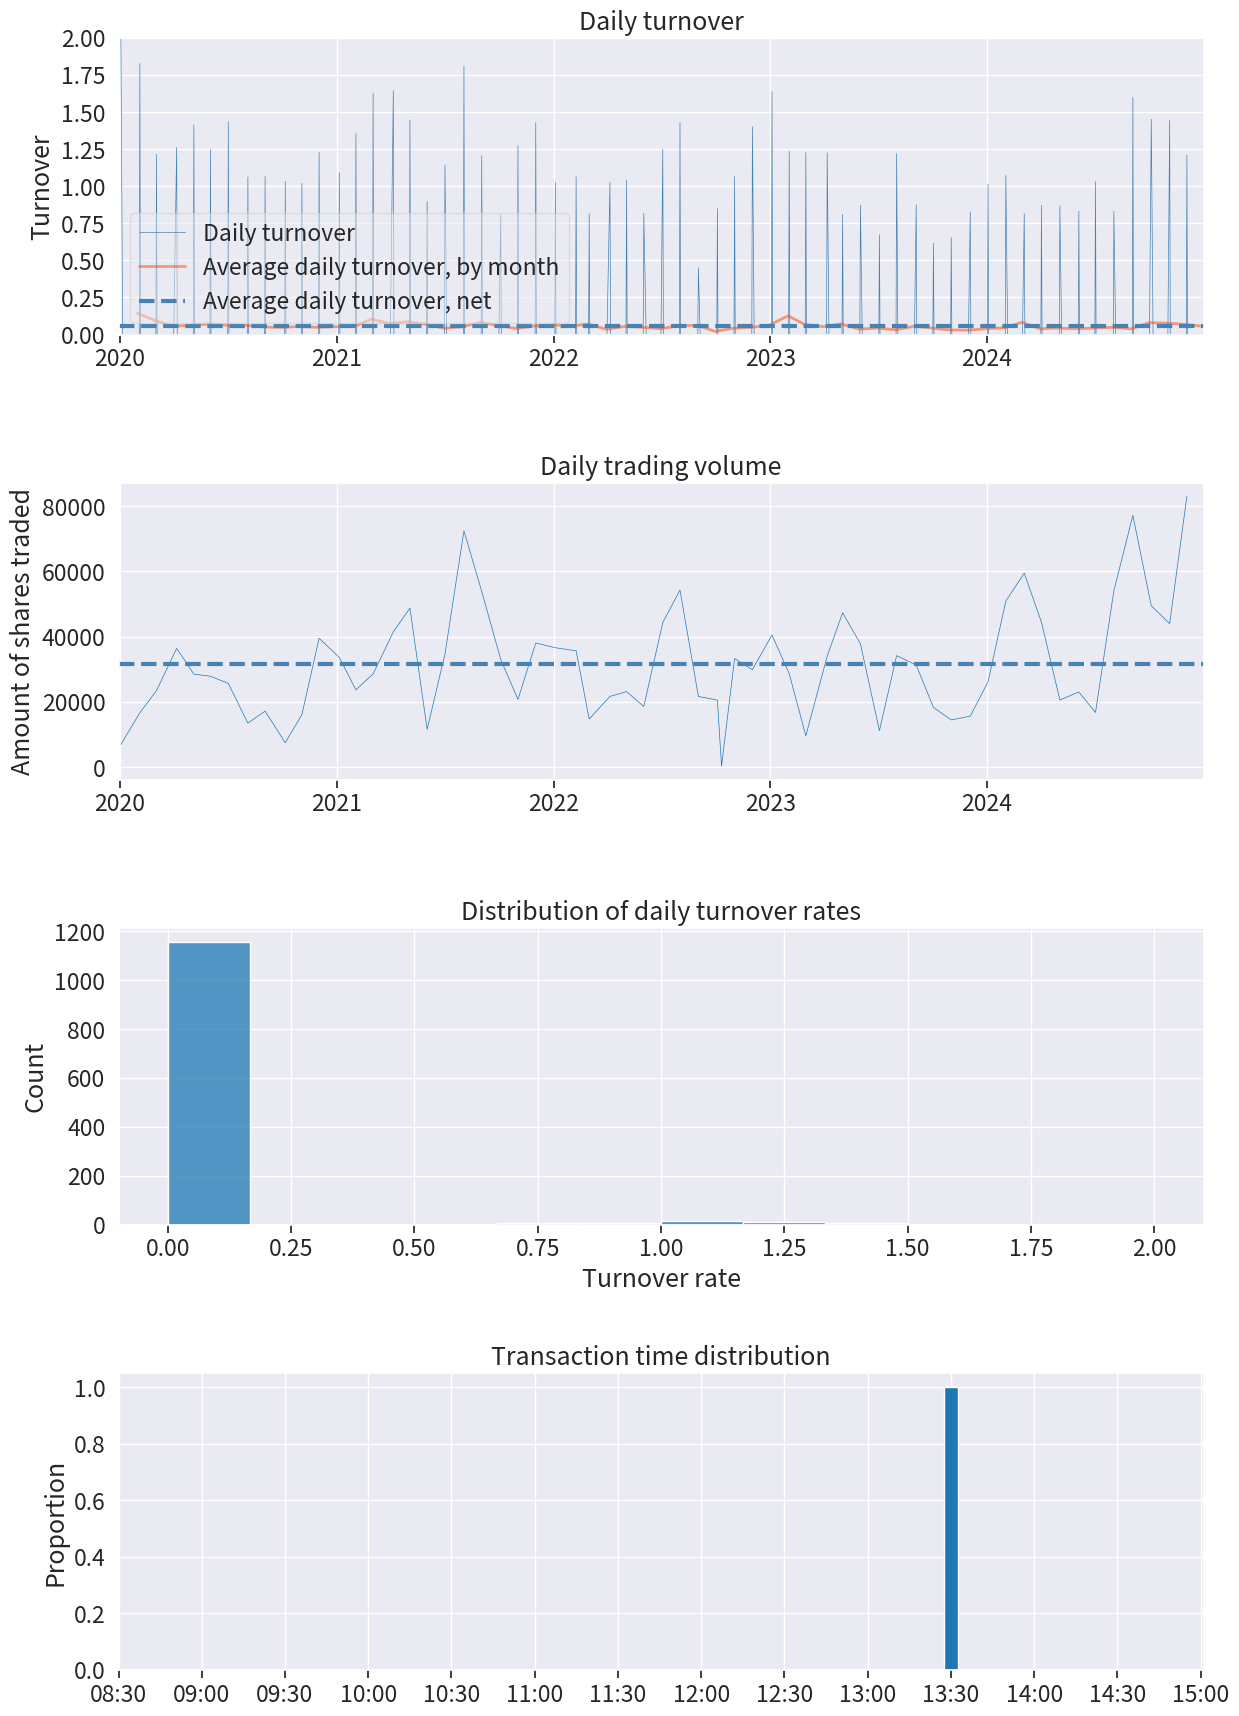

In [22]:
try:
    import pyfolio as pf
    from pyfolio.utils import extract_rets_pos_txn_from_zipline
    import logging
    logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
    
    returns, positions, transactions = extract_rets_pos_txn_from_zipline(results)
    benchmark_rets = results.benchmark_return

    pf.show_perf_stats(benchmark_rets)

    pf.tears.create_full_tear_sheet(
        returns=returns, positions=positions, transactions=transactions,
        benchmark_rets=results.benchmark_return,
    )
except ImportError:
    print('pip install pyfolio')
except Exception as e:
    print(f'Pyfolio error: {e}')
